## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from time import time

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
 )
from sklearn.utils.class_weight import compute_class_weight

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('Set2')

# Compatibility flag used in summary cell
IMBALANCED_LEARN_AVAILABLE = True

## Load Preprocessed Data

In [2]:
df = pd.read_csv('../data/data_features_engineering.csv')

In [3]:
target_col = 'income_target'

X = df.drop(columns=[target_col])
y = df[target_col]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
    shuffle=True,
 )

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

Training set: (36155, 113)
Test set: (9039, 113)
Features: 113


In [8]:
class_dist = y_train.value_counts(normalize=True) * 100
print('\nClass distribution in training set:')
for value, pct in class_dist.items():
    label = '>$50K' if value == 1 else '<=$50K'
    print(f'  {label} ({value}): {pct:.1f}%')


Class distribution in training set:
  <=$50K (0): 75.2%
  >$50K (1): 24.8%


In [9]:
# Calculate class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f'\nClass weights for balancing: {class_weight_dict}')


Class weights for balancing: {np.int64(0): np.float64(0.6648584038249357), np.int64(1): np.float64(2.0164528722810933)}


## Define Models to Train

In [10]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

## Cross-Validation Training and Evaluation

In [11]:
# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

# Fit model on full training set
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      6798
           1       0.58      0.84      0.68      2241

    accuracy                           0.81      9039
   macro avg       0.76      0.82      0.77      9039
weighted avg       0.85      0.81      0.82      9039



In [17]:
# Requested and supporting metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print(f'CV Accuracy: {cv_scores.mean():.4f} +- {cv_scores.std():.4f}')
print(f'CV AUC: {cv_auc.mean():.4f} +- {cv_auc.std():.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test F1: {test_f1:.4f}')
print(f'Test AUC: {test_auc:.4f}')

CV Accuracy: 0.8128 +- 0.0019
CV AUC: 0.9119 +- 0.0043
Test Accuracy: 0.8079
Test Precision: 0.5773
Test Recall: 0.8416
Test F1: 0.6848
Test AUC: 0.9078


## Visualize Model Performance

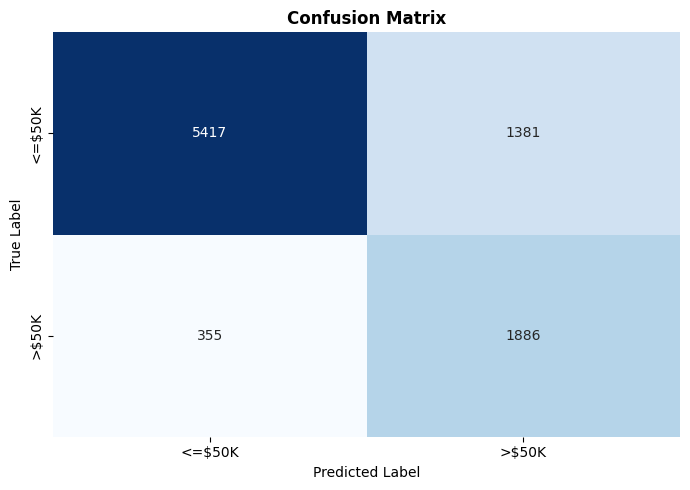

In [24]:
# 1) Confusion matrix heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['<=$50K', '>$50K'],
    yticklabels=['<=$50K', '>$50K'],
)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

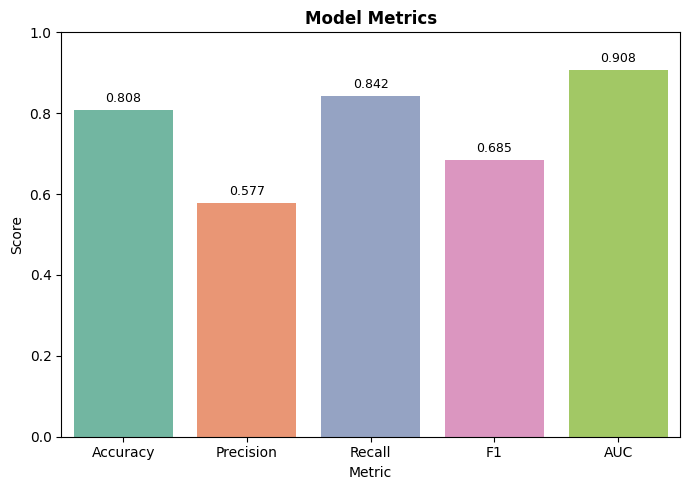

In [25]:
# 2) Metrics bar chart
metrics_to_plot = pd.DataFrame(
    {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
        'Value': [test_accuracy, test_precision, test_recall, test_f1, test_auc],
    }
)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=metrics_to_plot, x='Metric', y='Value', palette='Set2')
ax.set_ylim(0, 1)
ax.set_title('Model Metrics', fontweight='bold')
ax.set_ylabel('Score')
for i, v in enumerate(metrics_to_plot['Value']):
    ax.text(i, min(v + 0.02, 0.98), f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

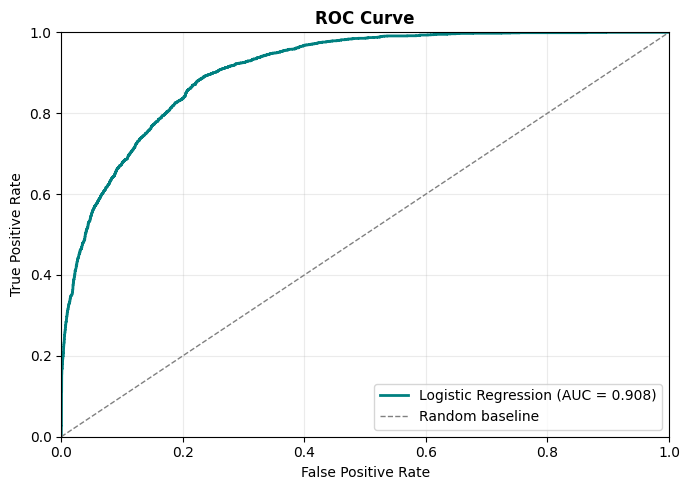

In [26]:
# 3) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='teal', linewidth=2, label=f'Logistic Regression (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random baseline')
plt.title('ROC Curve', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Save a model

In [ ]:
from pathlib import Path


# Prepare output directory and file paths
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'logistic_regression_model.pkl'
metadata_path = models_dir / 'logistic_regression_metadata.json'

# Save trained model
joblib.dump(model, model_path)

# Collect metadata from current run if available
model_metadata = {
    'model_name': 'Logistic Regression',
    'model_type': type(model).__name__,
    'features_used': X_train.columns.tolist() if 'X_train' in globals() else [],
    'training_samples': int(len(X_train)) if 'X_train' in globals() else None,
    'test_samples': int(len(X_test)) if 'X_test' in globals() else None,
    'test_accuracy': float(test_accuracy) if 'test_accuracy' in globals() else None,
    'test_precision': float(test_precision) if 'test_precision' in globals() else None,
    'test_recall': float(test_recall) if 'test_recall' in globals() else None,
    'test_f1': float(test_f1) if 'test_f1' in globals() else None,
    'test_auc': float(test_auc) if 'test_auc' in globals() else None,
    'confusion_matrix': cm.tolist() if 'cm' in globals() else None,
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: ..\models\logistic_regression_model.pkl
Metadata saved to: ..\models\logistic_regression_metadata.json
